In [8]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageDraw
from intersect_detection import get_bounding_boxes

(-0.5, 639.5, 639.5, -0.5)

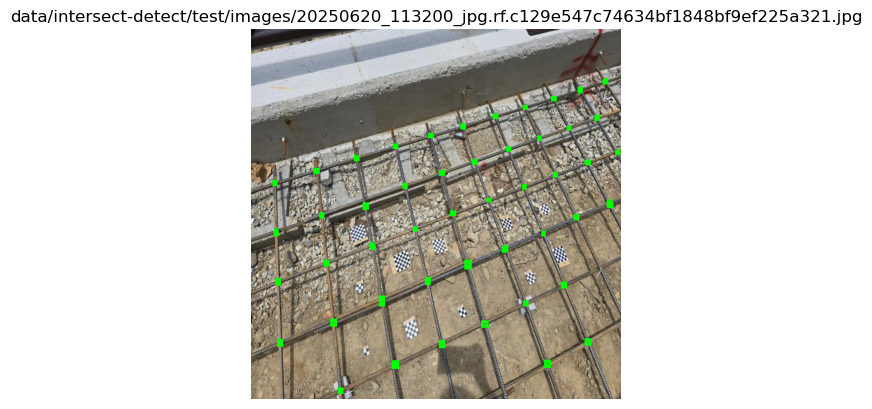

In [33]:
# image_path = "data/intersect-detect/test/images/20250620_115012_jpg.rf.239a32ab7bcbefe30fb9f388607d7048.jpg"
image_path = "data/intersect-detect/test/images/20250620_113200_jpg.rf.c129e547c74634bf1848bf9ef225a321.jpg"
model_path = "runs/detect/tune/weights/best.pt"

image = Image.open(image_path)
draw = ImageDraw.Draw(image)

bounding_boxes = get_bounding_boxes(image_path, model_path)
vertices = []
for box in bounding_boxes:
    x_center = (box[0] + box[2]) / 2
    y_center = (box[1] + box[3]) / 2
    vertices.append((x_center, y_center))
    draw.rectangle(box, outline="lime", width=5)
vertices = np.array(vertices)

# Display
fig = plt.subplot()
fig.imshow(image)
fig.set_title(f"{image_path}")
fig.axis('off')

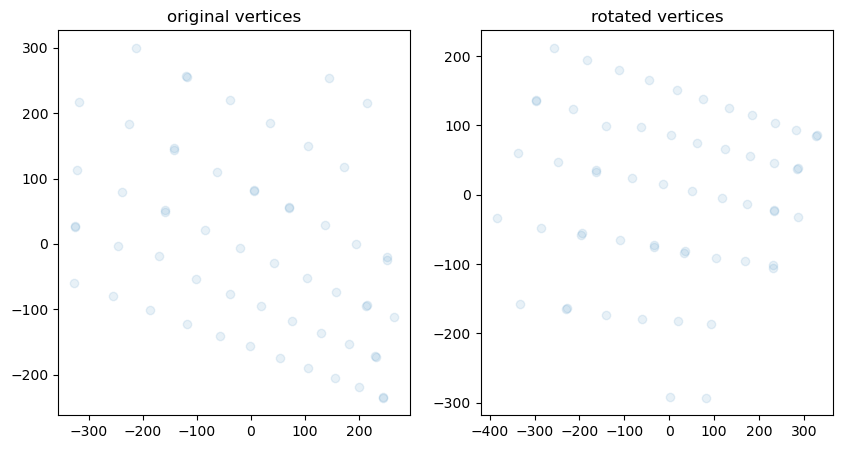

In [37]:
# Remove outliers
mean = np.mean(vertices, axis=0)
std = np.std(vertices, axis=0)
z_scores = np.abs((vertices - mean) / std)
vertices = vertices[(z_scores < 3).all(axis=1)]

# PCA Alignment
vc = vertices - mean
U, S, Vt = np.linalg.svd(vc) # 3 factors of matrix
vr = vc @ Vt.T 

# print("U matrix:\n", U) # Orthogonal matrix (rotate)
# print("U matrix shape:", U.shape)
# print("Singular values:\n", S) # Diagonal matrix (stretch)
# print("Vt matrix:\n", Vt) # Orthogonal matrix (rotate)

plt.figure(figsize=(10, 5))
plt.subplot(1,2,1)
plt.title('original vertices')
plt.scatter(vc[:, 0], vc[:, 1], alpha=0.1)
plt.subplot(1,2,2)
plt.title('rotated vertices')
plt.scatter(vr[:, 0], vr[:, 1], alpha=0.1)